In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dice-ml to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

# Load data
data = pd.read_csv('/content/drive/MyDrive/DS Project/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

In [ ]:
import json

with open("/content/drive/MyDrive/DS Project/data_info.json", "r") as f:
    data_info = json.load(f)

In [ ]:
for col in data.columns:
    if data[col].isna().any():
        print(col, data[col].isna().sum())

In [ ]:
# Handle missing data and changing column type
for col_name, info in data_info.items():
    print(col_name)
    if info["type"] == "int64":
        if col_name == "Zip Code - 3 digits":
            data[col_name] = data[col_name].replace("OOS", 000)
            data[col_name] = data[col_name].fillna(000)
        if col_name == "Length of Stay":
            data[col_name] = data[col_name].replace("120 +", 121)
        if col_name == "Birth Weight":
            data[col_name] = data[col_name].replace("UNKN", -1)
            data[col_name] = data[col_name].fillna(-1)
        else:
            data[col_name] = data[col_name].fillna(-1)

        data[col_name] = pd.to_numeric(data[col_name]).astype('int')

    elif info["type"] == "str":
        data[col_name] = data[col_name].fillna("Unknown")
        data[col_name] = data[col_name].astype(str)

    elif info["type"] == "float64":
        data[col_name] = data[col_name].str.replace(',', '')
        data[col_name] = pd.to_numeric(data[col_name]).astype('float')


In [ ]:
for col in data.columns:
    if data[col].isna().any():
        print(col, data[col].isna().sum())

In [ ]:
for col in data.columns:
    print(col, data[col].dtype)

In [ ]:
categorical_columns = []
for col in data.columns:
    print(col, data[col].dtype)
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category')
        categorical_columns.append(col)
print(categorical_columns)

In [ ]:
X = data.drop(columns=['Total Costs', ])
y = data['Total Costs']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.to_csv('/content/drive/MyDrive/DS Project/preprocessed_X_train.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/DS Project/preprocessed_y_train.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/DS Project/preprocessed_X_test.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/DS Project/preprocessed_y_test.csv', index=False)

In [ ]:
full_df = pd.concat([X_train, X_test])
full_df['Total Costs'] = pd.concat([y_train, y_test]).values
full_df.to_csv('/content/drive/MyDrive/DS Project/preprocessed_full_data.csv', index=False)

In [ ]:
# Save categorical columns metadata
with open('/content/drive/MyDrive/DS Project/categorical_columns.txt', 'w') as f:
    f.write(','.join(categorical_columns))

In [ ]:
#Save category mappings for each column (important!)
for col in categorical_columns:
    cat_map = dict(enumerate(X_train[col].cat.categories))
    with open(f'/content/drive/MyDrive/DS Project/category_mapping_{col}.txt', 'w') as f:
        for code, category in cat_map.items():
            f.write(f"{code},{category}\n")

print("Data saved successfully!")
print(f"Detected categorical columns: {categorical_columns}")

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import dice_ml
from dice_ml import Dice
import joblib

In [4]:
import joblib
import dice_ml
import pandas as pd
import numpy as np
import os
from sklearn.base import BaseEstimator, RegressorMixin
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# 1. Configuration
# ----------------------------
target_col = 'Total Costs'
model_paths = {
     'LightGBM': '/content/drive/MyDrive/DS Project/lgb_model.pkl',
     'XGBoost': '/content/drive/MyDrive/DS Project/xgb_model.pkl',
    #'CatBoost': '/content/drive/MyDrive/DS Project/catb_model.pkl',
    #'AdaBoost': '/content/drive/MyDrive/DS Project/adab_model.pkl'
}
cf_target = [3000, 9000]  # Adjusted target range

# Paths to your data files
X_train_path = '/content/drive/MyDrive/DS Project/preprocessed_X_train.csv'
X_test_path = '/content/drive/MyDrive/DS Project/preprocessed_X_test.csv'
y_train_path = '/content/drive/MyDrive/DS Project/preprocessed_y_train.csv'
y_test_path = '/content/drive/MyDrive/DS Project/preprocessed_y_test.csv'

# Directory for categorical mappings
mappings_dir = '/content/drive/MyDrive/DS Project/'

# ----------------------------
# 2. Helper: enforce category dtype for categorical columns
# ----------------------------
def enforce_category_dtype(df, categorical_columns, category_mappings):
    """
    Ensures all categorical columns in df are of type 'category' and have correct categories.
    """
    for col in categorical_columns:
        if col in df.columns and col in category_mappings:
            cat_dtype = pd.CategoricalDtype(categories=category_mappings[col], ordered=False)
            # Always convert to string first, then to categorical (prevents code/label mix)
            df[col] = df[col].astype(str).astype(cat_dtype)
    return df

# ----------------------------
# 3. Load Data and Models
# ----------------------------
# Load features
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

# Load targets
y_train = pd.read_csv(y_train_path, header=None, names=[target_col], dtype=float, skiprows=1)
y_test = pd.read_csv(y_test_path, header=None, names=[target_col], dtype=float, skiprows=1)

# Create combined dataset for DiCE
full_df = pd.concat([
    X_train.reset_index(drop=True),
    X_test.reset_index(drop=True)
], ignore_index=True)
full_df[target_col] = pd.concat([
    y_train.reset_index(drop=True),
    y_test.reset_index(drop=True)
], ignore_index=True)[target_col]

# Load models
models = {}
for name, path in model_paths.items():
    models[name] = joblib.load(path)

# ----------------------------
# 4. Load Categorical Metadata from TXT Files
# ----------------------------
categorical_columns = []
category_mappings = {}

mapping_files = [f for f in os.listdir(mappings_dir)
                 if f.startswith('category_mapping_') and f.endswith('.txt')]

for file in mapping_files:
    col_name = file.replace('category_mapping_', '').replace('.txt', '')
    if col_name:
        categorical_columns.append(col_name)
        mapping = {}
        categories = []
        with open(os.path.join(mappings_dir, file), 'r') as f:
            for line in f:
                parts = line.strip().split(',', 1)
                if len(parts) == 2:
                    code, category = parts
                    try:
                        mapping[int(code)] = category
                        categories.append(category)
                    except ValueError:
                        print(f"Skipping invalid code in {file}: {code}")
        if mapping:
            sorted_categories = [mapping[k] for k in sorted(mapping.keys())]
            category_mappings[col_name] = sorted_categories
            print(f"Loaded {len(sorted_categories)} categories for {col_name}")
        else:
            print(f"Warning: No valid mappings found for {col_name}")

print("\nValid categorical features:", [col for col in categorical_columns if col in category_mappings])

# Identify continuous features
continuous_features = [col for col in X_train.columns if col not in categorical_columns]
print("Continuous features:", continuous_features)

# ----------------------------
# 5. Ensure Categorical Consistency in All DataFrames
# ----------------------------
X_train = enforce_category_dtype(X_train, categorical_columns, category_mappings)
X_test = enforce_category_dtype(X_test, categorical_columns, category_mappings)
full_df = enforce_category_dtype(full_df, categorical_columns, category_mappings)

# ----------------------------
# 6. Create DiCE Data Object
# ----------------------------
dice_data = dice_ml.Data(
    dataframe=full_df,
    continuous_features=continuous_features,
    categorical_features=[col for col in categorical_columns if col in category_mappings],
    outcome_name=target_col
)

# ----------------------------
# 7. Prepare Query Instance
# ----------------------------
query_index = 0  # First test sample
query_instance = X_test.iloc[[query_index]].copy()
query_instance = enforce_category_dtype(query_instance, categorical_columns, category_mappings)

print("\n[DEBUG] Query instance dtypes:")
print(query_instance.dtypes)
print("\nOriginal Instance:")
print(query_instance[list(category_mappings.keys())].head())
print("\nActual Target Value:", y_test.iloc[query_index].values[0])

# ----------------------------
# 8. Model Wrapper for DiCE Compatibility
# ----------------------------
class ModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, category_mappings):
        self.model = model
        self.category_mappings = category_mappings

    def predict(self, X):
        X_converted = X.copy()
        # Enforce category dtype for all categorical columns
        for col in self.category_mappings:
            if col in X_converted.columns:
                cat_dtype = pd.CategoricalDtype(categories=self.category_mappings[col], ordered=False)
                X_converted[col] = X_converted[col].astype(str).astype(cat_dtype)
        return self.model.predict(X_converted)

# ----------------------------
# 9. Generate Counterfactuals
# ----------------------------
results = []

for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")

    # Wrap the model for DiCE compatibility
    wrapped_model = ModelWrapper(model, category_mappings)

    try:
        pred = wrapped_model.predict(query_instance)[0]
        print(f"Predicted Value: {pred:.4f}")
    except Exception as e:
        print(f"Prediction failed: {e}")
        continue

    # Create DiCE model object
    try:
        dice_model = dice_ml.Model(
            model=wrapped_model,
            backend="sklearn",
            model_type='regressor'
        )
    except Exception as e:
        print(f"DiCE model creation failed: {e}")
        continue

    # Initialize DiCE explainer
    try:
        dice_explainer = dice_ml.Dice(
            dice_data,
            dice_model,
            method="kdtree"
        )
    except Exception as e:
        print(f"DiCE initialization failed: {e}")
        continue

    # Generate counterfactuals
    try:
        counterfactuals = dice_explainer.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_range=cf_target,
            proximity_weight=0.3,
            diversity_weight=0.5,
            categorical_penalty=0.05,
            verbose=False,
            posthoc_sparsity_param=0.1
        )
    except Exception as e:
        print(f"Counterfactual generation failed: {e}")
        continue

    # Visualize results
    print("\nCounterfactual Explanations:")
    counterfactuals.visualize_as_dataframe(show_only_changes=True)

    # Get counterfactuals as DataFrame
    try:
        cf_df = counterfactuals.cf_examples_list[0].final_cfs_df
        # Add metadata
        cf_df['model'] = model_name
        cf_df['original_index'] = query_index
        cf_df['original_prediction'] = pred
        results.append(cf_df)
    except Exception as e:
        print(f"Error processing counterfactuals: {e}")

# ----------------------------
# 10. Save and Analyze Results
# ----------------------------
if results:
    all_cfs = pd.concat(results)

    # Convert categorical columns to strings for saving
    for col in categorical_columns:
        if col in all_cfs.columns:
            all_cfs[col] = all_cfs[col].astype(str)

    all_cfs.to_csv('counterfactual_results.csv', index=False)
    print("\nAll counterfactuals saved to counterfactual_results.csv")

    # Analysis: Most frequently changed features
    if not all_cfs.empty:
        changed_features = []
        original_row = query_instance.iloc[0]

        for _, cf_row in all_cfs.iterrows():
            for col in query_instance.columns:
                if col in cf_row and col in original_row:
                    if str(cf_row[col]) != str(original_row[col]):
                        changed_features.append(col)

        if changed_features:
            from collections import Counter
            print("\nMost frequently changed features:")
            for feature, count in Counter(changed_features).most_common(10):
                print(f"- {feature}: {count} times")
        else:
            print("\nNo features changed in counterfactuals")
else:
    print("No counterfactuals generated for any model")

print("\nCounterfactual generation complete!")


Loaded 9 categories for Hospital Service Area
Loaded 58 categories for Hospital County
Loaded 206 categories for Facility Name
Loaded 5 categories for Age Group
Loaded 3 categories for Gender
Loaded 4 categories for Race
Loaded 4 categories for Ethnicity
Loaded 6 categories for Type of Admission
Loaded 19 categories for Patient Disposition
Loaded 480 categories for CCSR Diagnosis Code
Loaded 480 categories for CCSR Diagnosis Description
Loaded 322 categories for CCSR Procedure Code
Loaded 322 categories for CCSR Procedure Description
Loaded 334 categories for APR DRG Description
Loaded 26 categories for APR MDC Description
Loaded 5 categories for APR Severity of Illness Code
Loaded 5 categories for APR Severity of Illness Description
Loaded 5 categories for APR Risk of Mortality
Loaded 3 categories for APR Medical Surgical Description
Loaded 9 categories for Payment Typology 1
Loaded 10 categories for Payment Typology 2
Loaded 10 categories for Payment Typology 3
Loaded 2 categories fo

100%|██████████| 1/1 [07:25<00:00, 445.99s/it]


Counterfactual Explanations:
Query instance (original outcome : 4241)


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Erie,1401014,207,Buffalo General Medical Center,70 or Older,140,F,White,Not Span/Hispanic,...,Minor,Moderate,Medical,Medicare,Self-Pay,Unknown,-1,Y,11499.469727,4241.292038



Diverse Counterfactual set (new outcome: [3000, 9000])


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
1682746,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,11499.5,4241.2919921875
805060,-,-,-,208.0,John R. Oishei Children's Hospital,0 to 17,-,M,-,-,...,-,Minor,-,Private Health Insurance,-,-,-,-,11482.5,4359.77197265625
457353,-,-,-,208.0,John R. Oishei Children's Hospital,30 to 49,-,-,Black/African American,-,...,-,Minor,-,Medicaid,-,-,-,N,11490.8,7725.42919921875



Model: XGBoost
Predicted Value: 4661.2246


100%|██████████| 1/1 [07:06<00:00, 426.80s/it]


Counterfactual Explanations:
Query instance (original outcome : 4661)


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Erie,1401014,207,Buffalo General Medical Center,70 or Older,140,F,White,Not Span/Hispanic,...,Minor,Moderate,Medical,Medicare,Self-Pay,Unknown,-1,Y,11499.469727,4661.224609



Diverse Counterfactual set (new outcome: [3000, 9000])


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
1682746,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,11499.5,-
805060,-,-,-,208.0,John R. Oishei Children's Hospital,0 to 17,-,M,-,-,...,-,Minor,-,Private Health Insurance,-,-,-,-,11482.5,4880.82666015625
1092586,-,-,1401008.0,213.0,Mercy Hospital of Buffalo,-,-,-,-,-,...,Moderate,-,-,-,Unknown,-,-,-,11486.2,3852.01318359375



All counterfactuals saved to counterfactual_results.csv

Most frequently changed features:
- Operating Certificate Number: 6 times
- Permanent Facility Id: 6 times
- Zip Code - 3 digits: 6 times
- Length of Stay: 6 times
- Discharge Year: 6 times
- APR DRG Code: 6 times
- APR MDC Code: 6 times
- Birth Weight: 6 times
- Total Charges: 6 times
- Facility Name: 4 times

Counterfactual generation complete!


In [9]:
import joblib

model = joblib.load("/content/drive/MyDrive/DS Project/lgb_model.pkl")

In [10]:
import shap

# Explain model predictions using SHAP
explainer = shap.Explainer(model)

In [11]:
# Save explainer to a file
joblib.dump(explainer, '/content/drive/MyDrive/DS Project/shap_explainer.pkl')

# Later: load it back
explainer = joblib.load('/content/drive/MyDrive/DS Project/shap_explainer.pkl')

In [12]:
def enforce_category_dtype(df, categorical_columns, category_mappings):
    for col in categorical_columns:
        if col in df.columns and col in category_mappings:
            cat_dtype = pd.CategoricalDtype(categories=category_mappings[col], ordered=False)
            df[col] = df[col].astype(str).astype(cat_dtype)
    return df

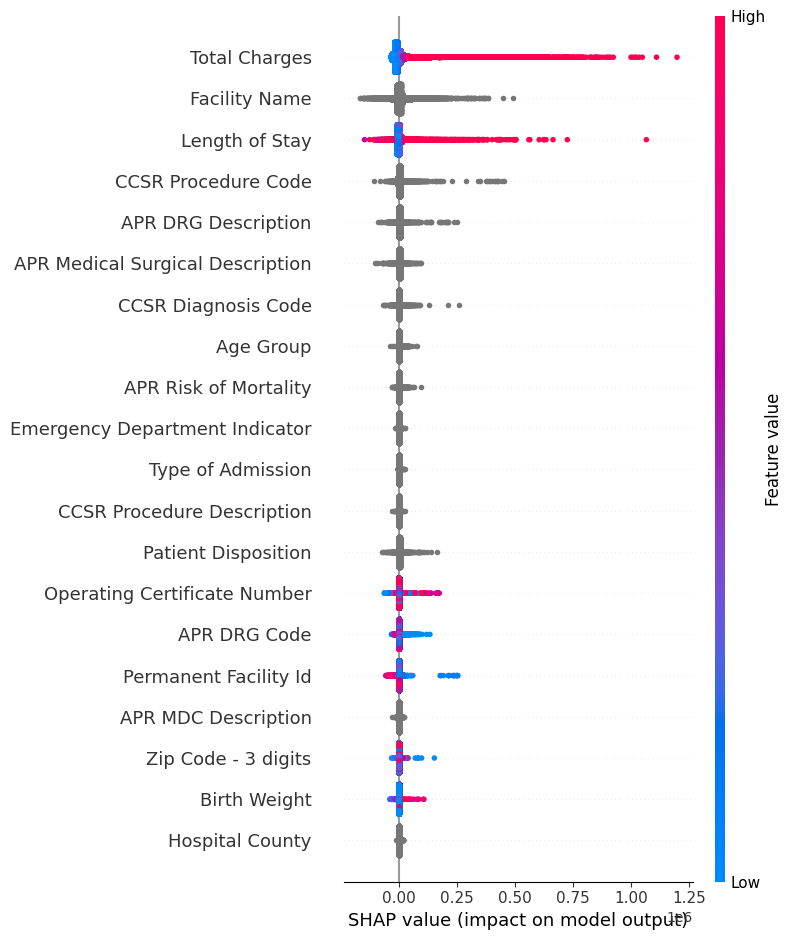

In [13]:
# Paths to your data files
X_train_path = '/content/drive/MyDrive/DS Project/preprocessed_X_train.csv'
X_test_path = '/content/drive/MyDrive/DS Project/preprocessed_X_test.csv'
y_train_path = '/content/drive/MyDrive/DS Project/preprocessed_y_train.csv'
y_test_path = '/content/drive/MyDrive/DS Project/preprocessed_y_test.csv'

# Directory for categorical mappings
mappings_dir = '/content/drive/MyDrive/DS Project/'

# ----------------------------
# 2. Load Data and Models
# ----------------------------
# ----------------------------
# 2. Load Data and Models
# ----------------------------
# Load features
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

# Ensure categoricals match exactly for both train and test!
X_train = enforce_category_dtype(X_train, categorical_columns, category_mappings)
X_test = enforce_category_dtype(X_test, categorical_columns, category_mappings)

# Load targets
# Skip the header row when loading target variables
y_train = pd.read_csv(y_train_path, header=None, names=[target_col], dtype=float, skiprows=1)
y_test = pd.read_csv(y_test_path, header=None, names=[target_col], dtype=float, skiprows=1)
# Visualize feature importance
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

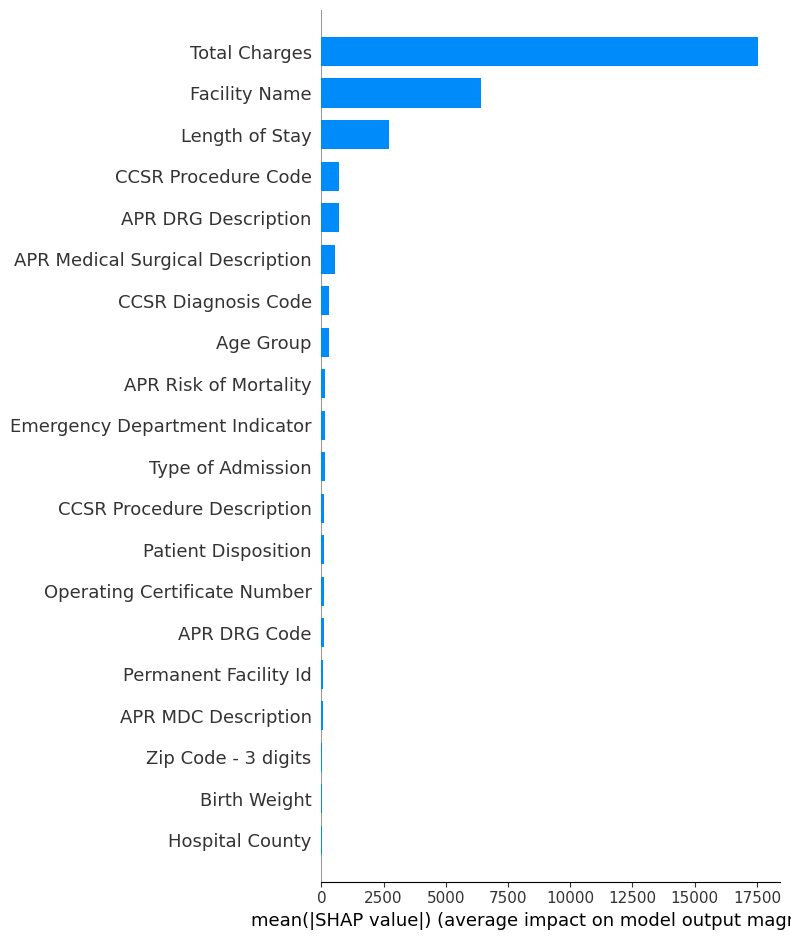

In [14]:
features = X_test.columns.tolist()
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar")

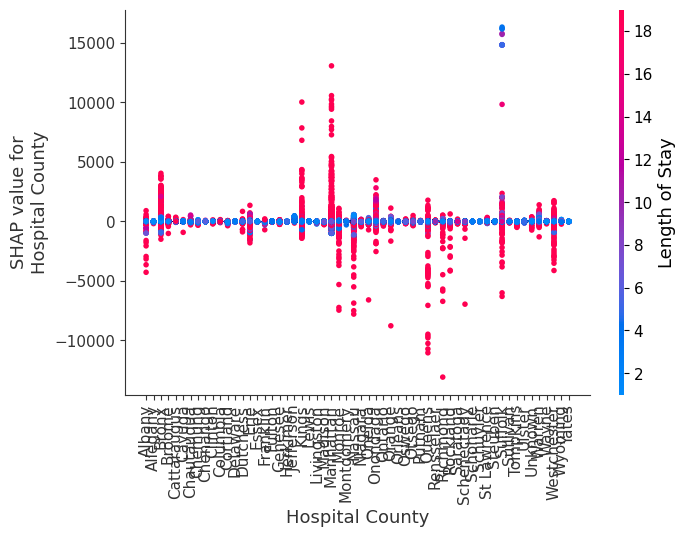

In [15]:
feature_index = 1
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

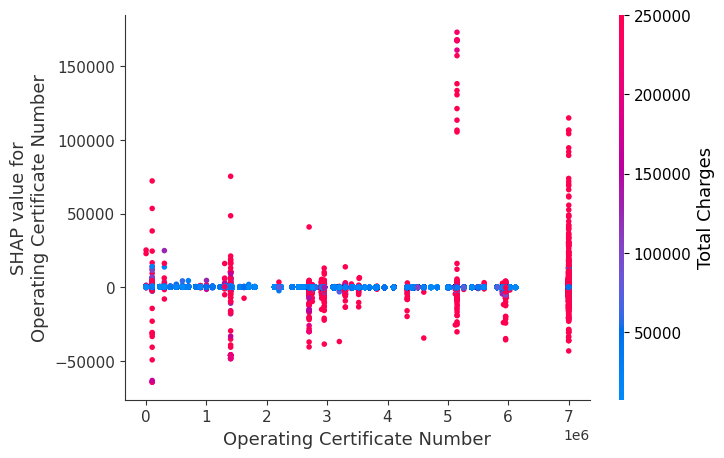

In [16]:
feature_index = 2
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

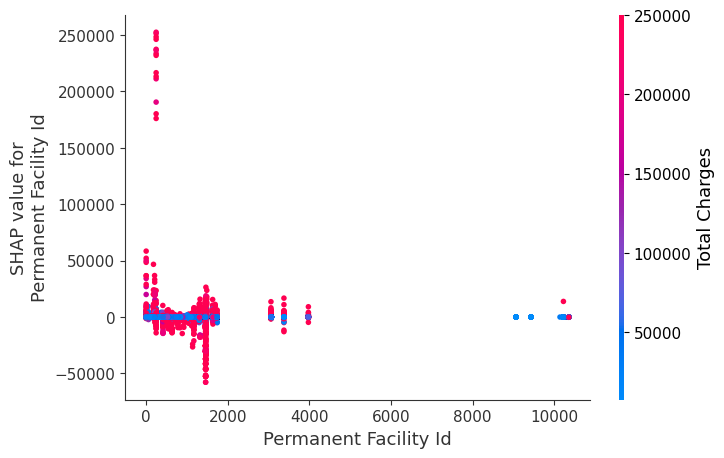

In [17]:
feature_index = 3
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

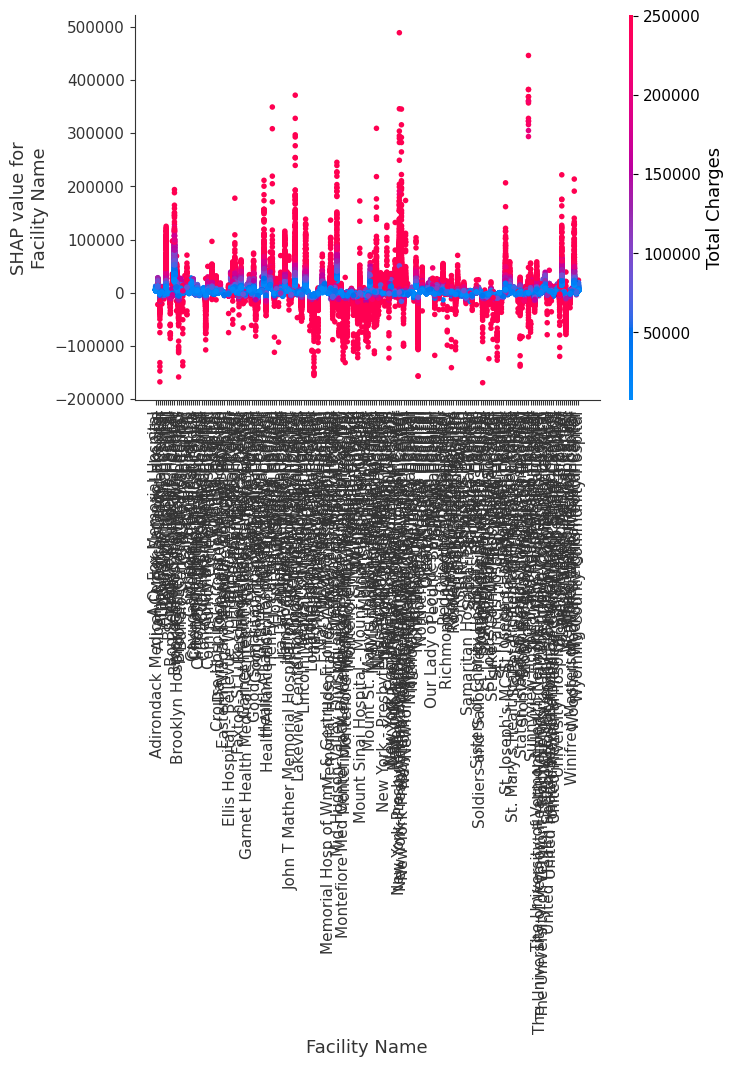

In [18]:
feature_index = 4
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

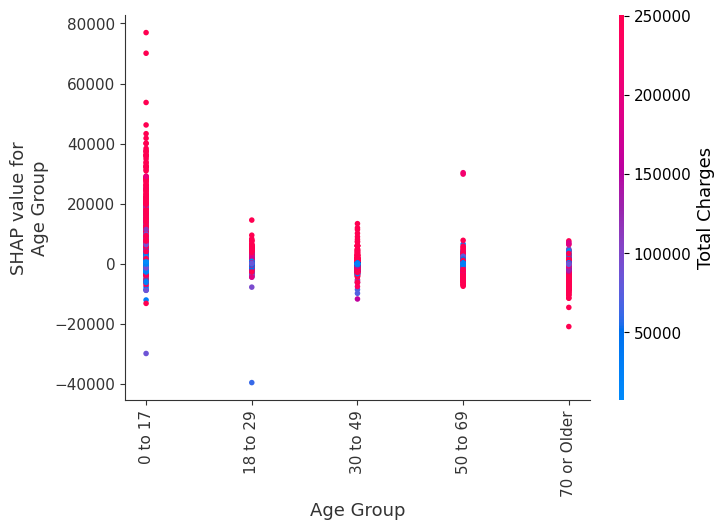

In [19]:
feature_index = 5
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

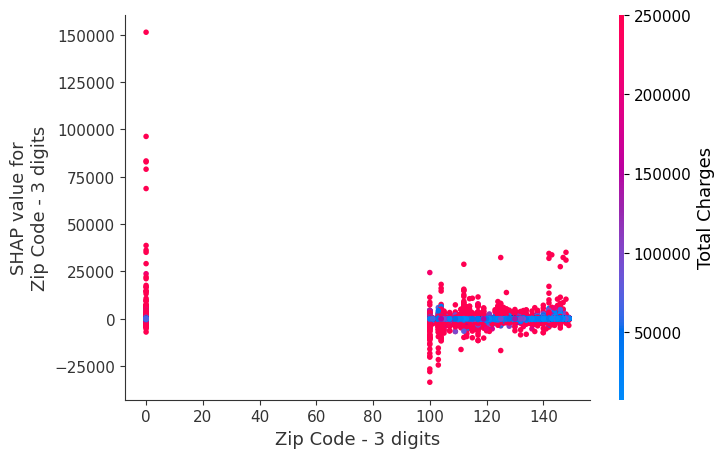

In [20]:
feature_index = 6
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

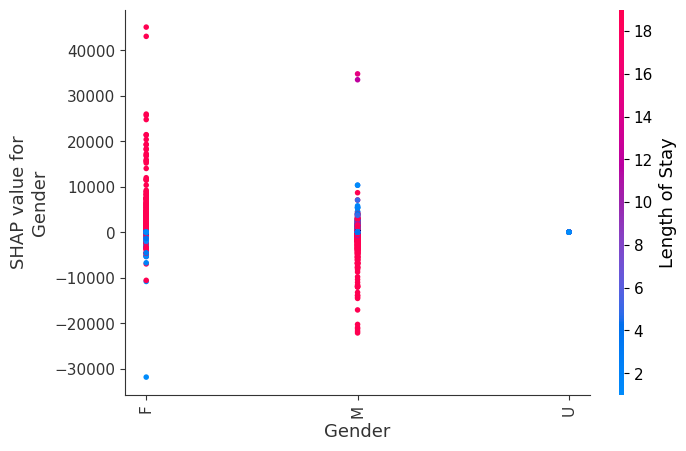

In [21]:
feature_index = 7
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

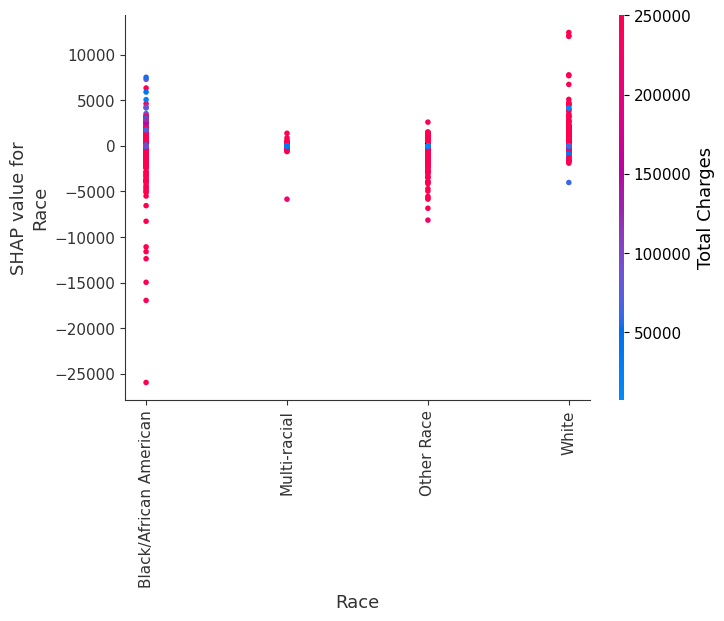

In [22]:
feature_index = 8
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

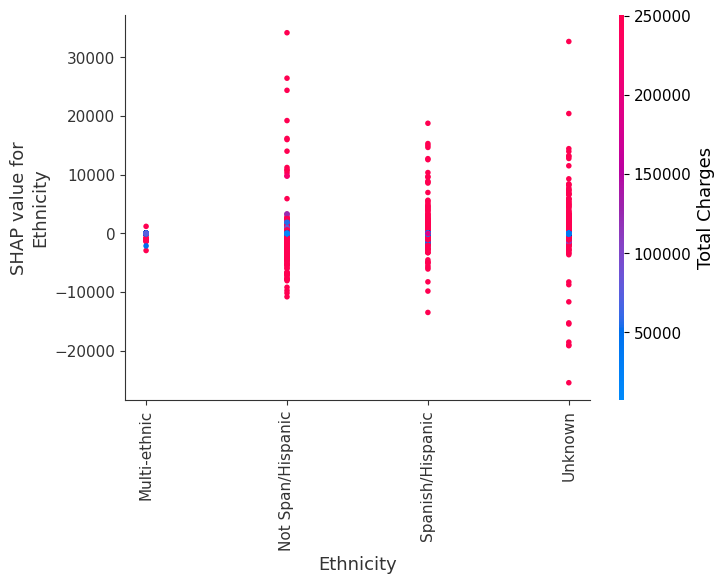

In [23]:
feature_index = 9
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

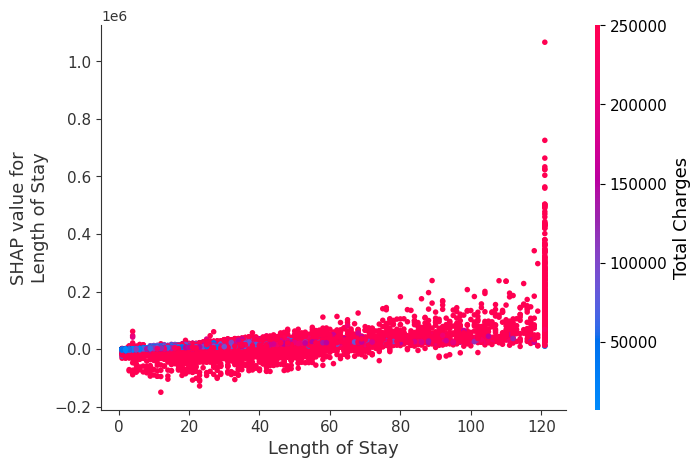

In [24]:
feature_index = 10
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

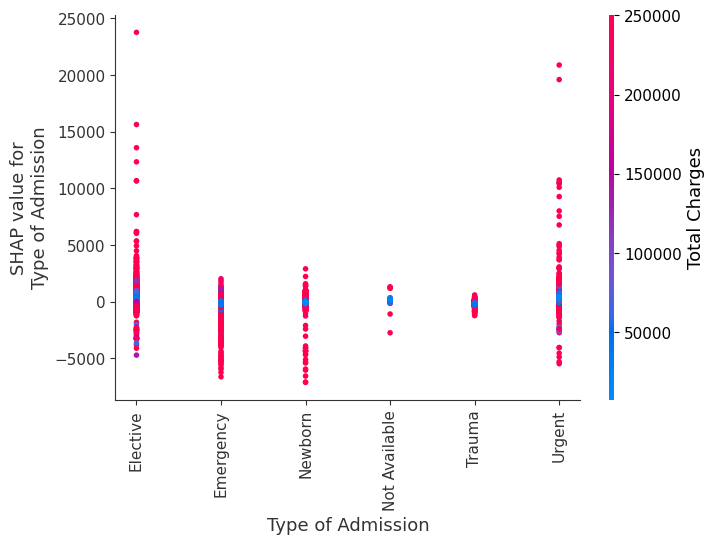

In [25]:
feature_index = 11
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

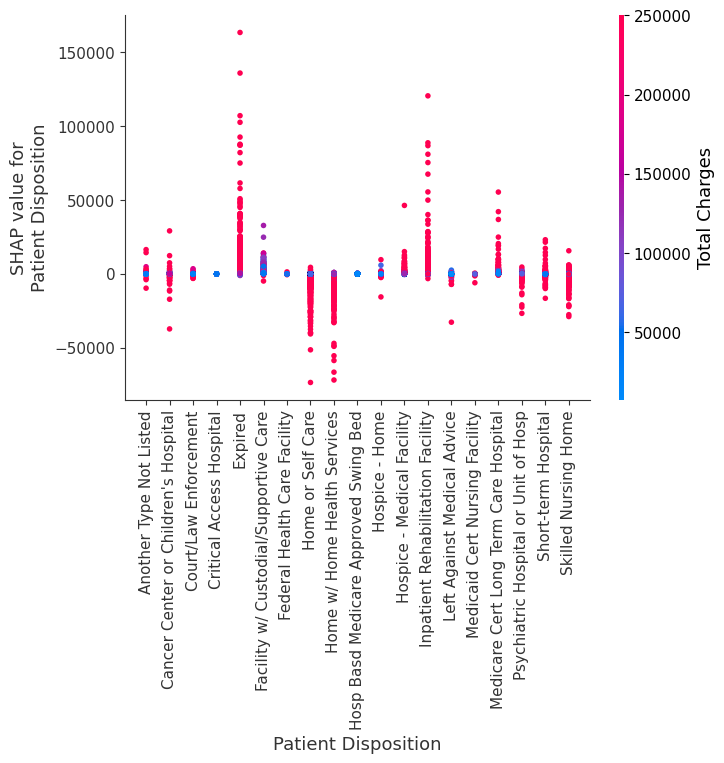

In [26]:
feature_index = 12
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

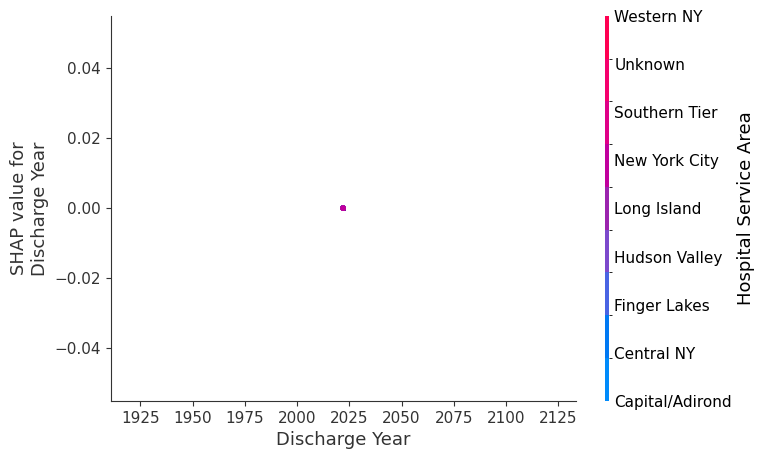

In [27]:
feature_index = 13
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

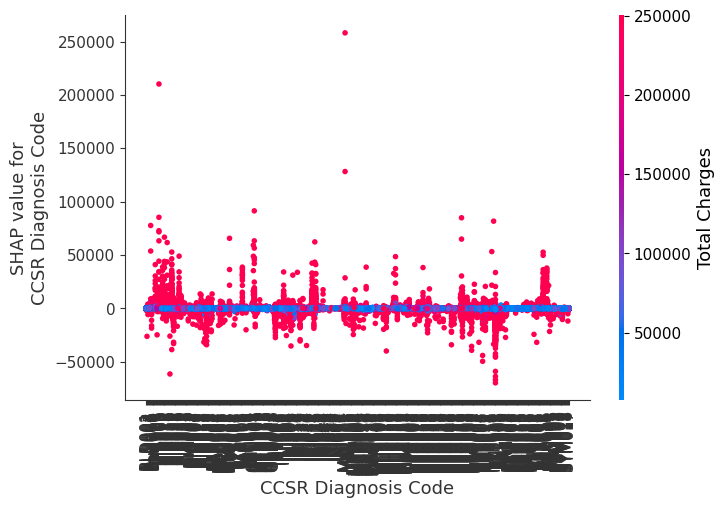

In [28]:
feature_index = 14
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

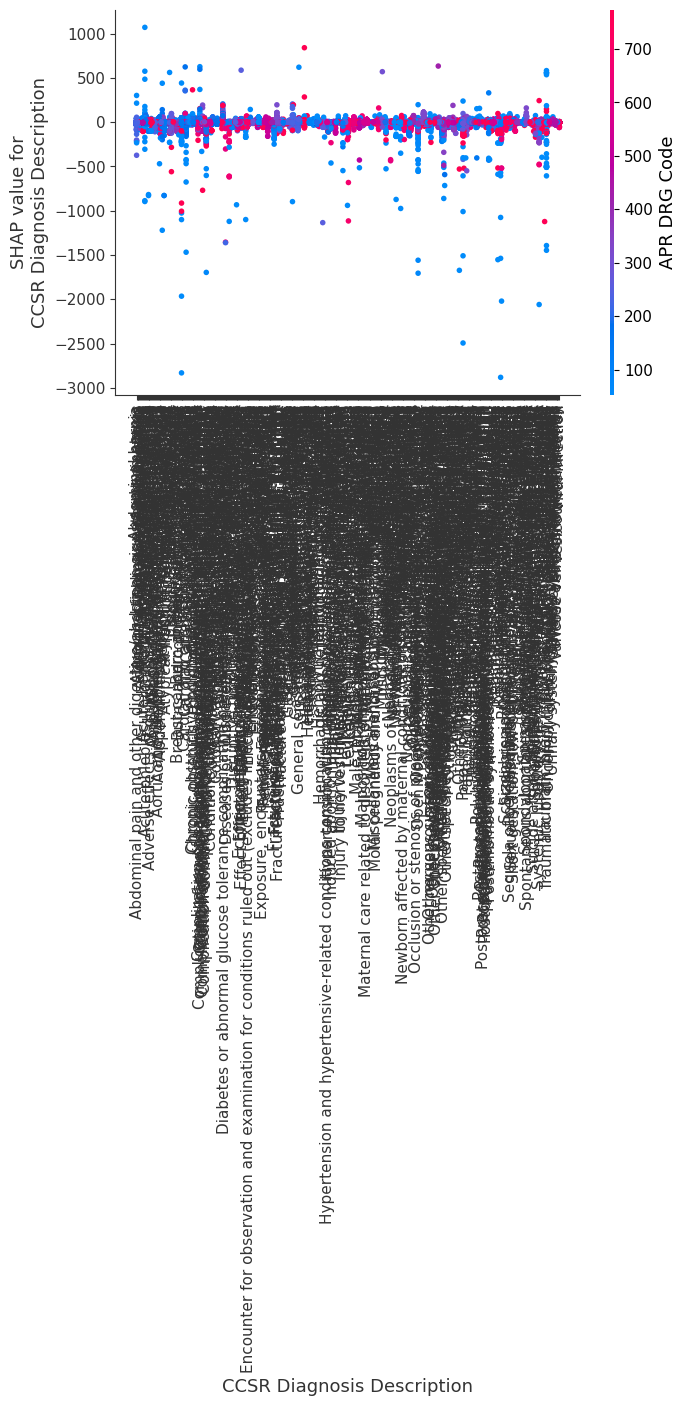

In [29]:
feature_index = 15
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

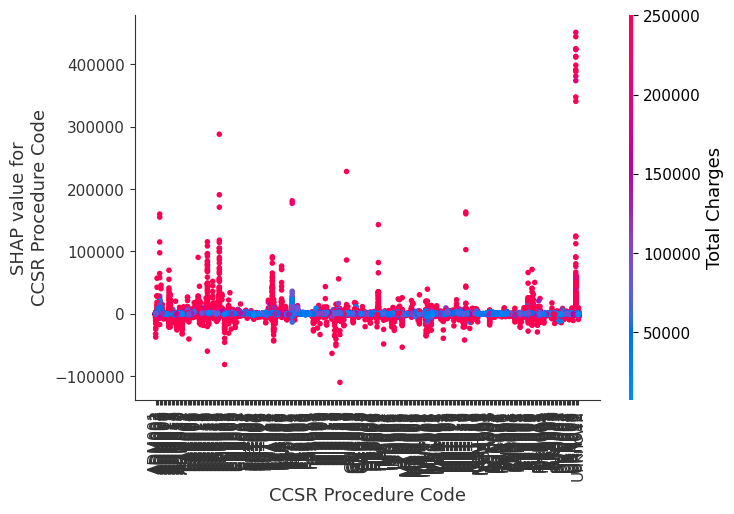

In [30]:
feature_index = 16
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

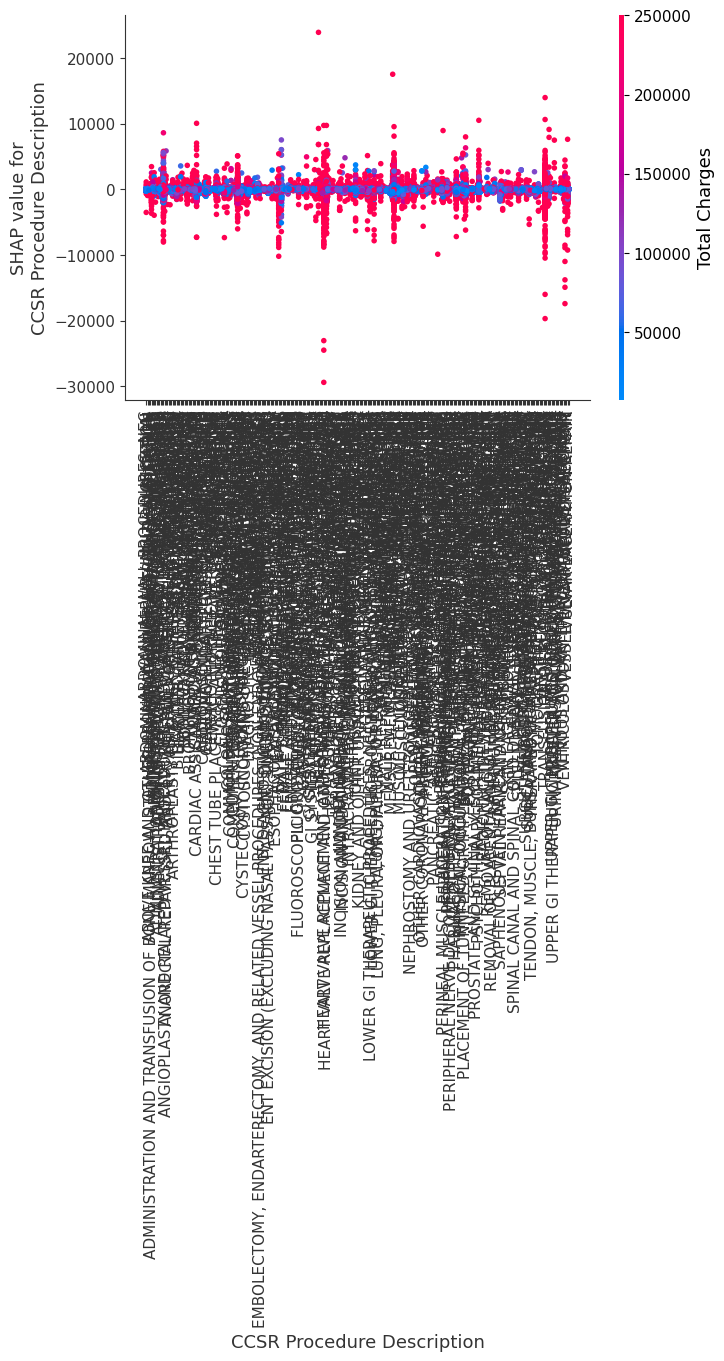

In [31]:
feature_index = 17
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

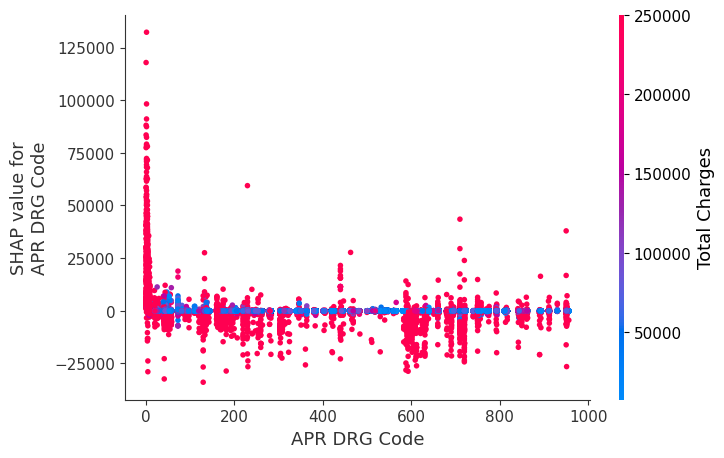

In [32]:
feature_index = 18
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

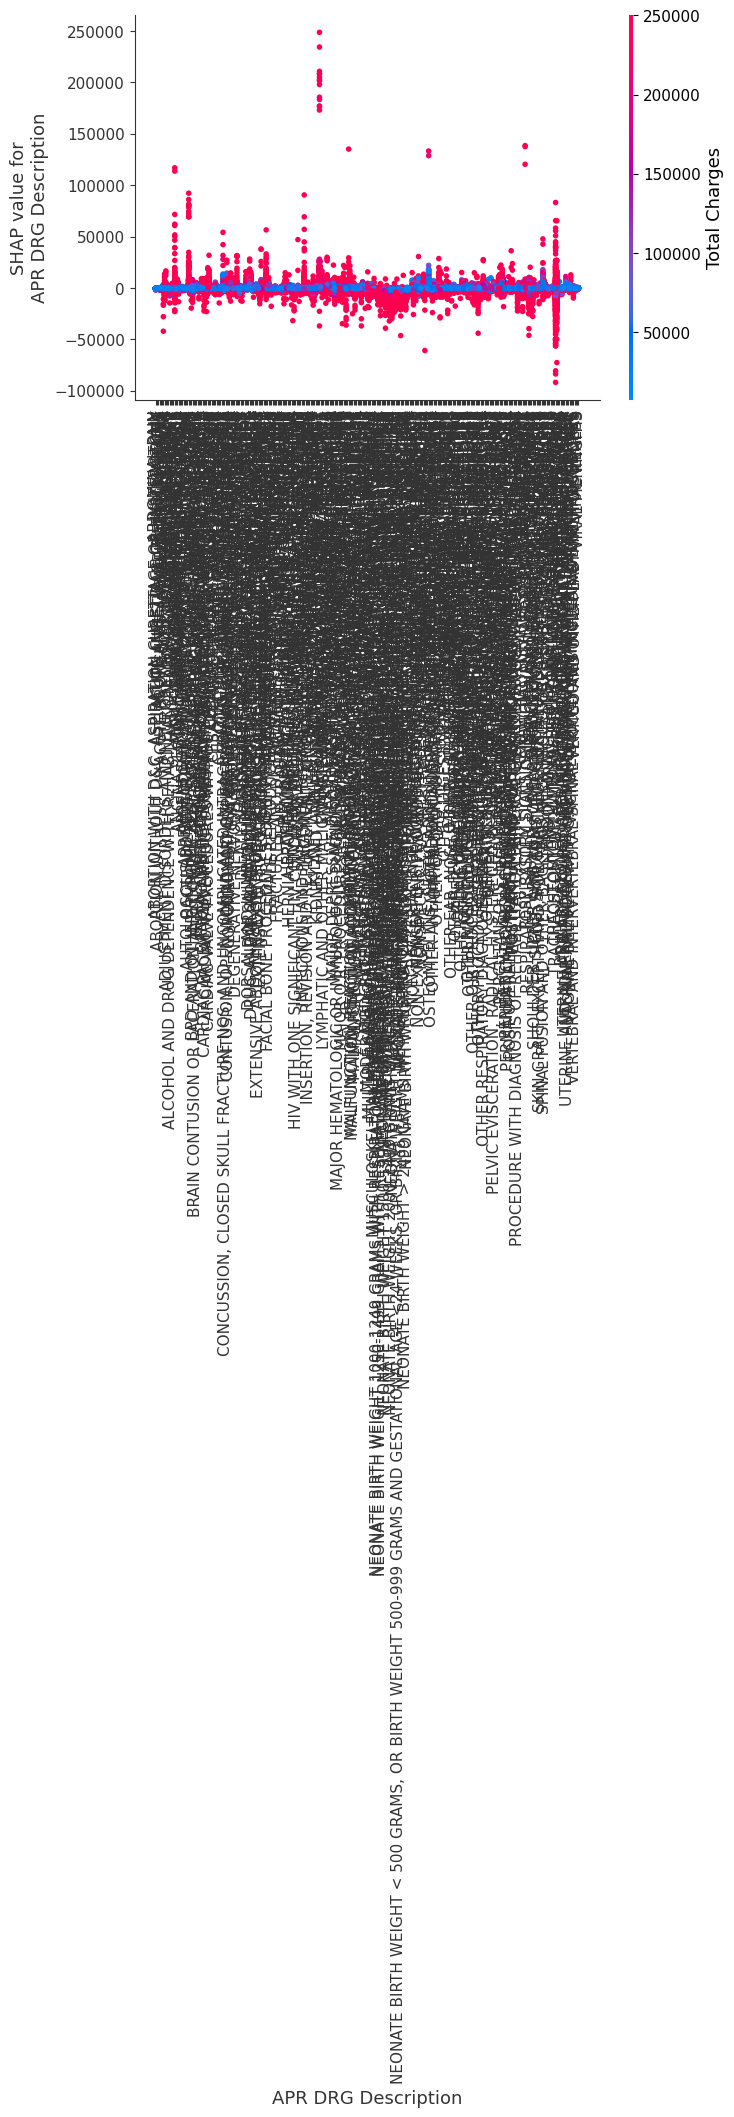

In [33]:
feature_index = 19
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

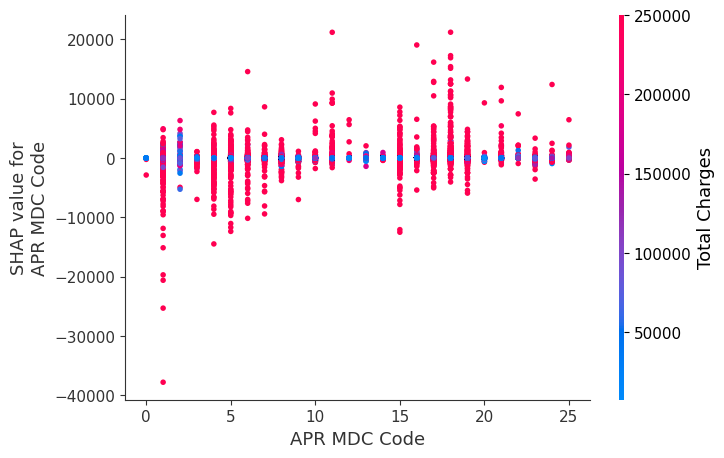

In [34]:
feature_index = 20
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

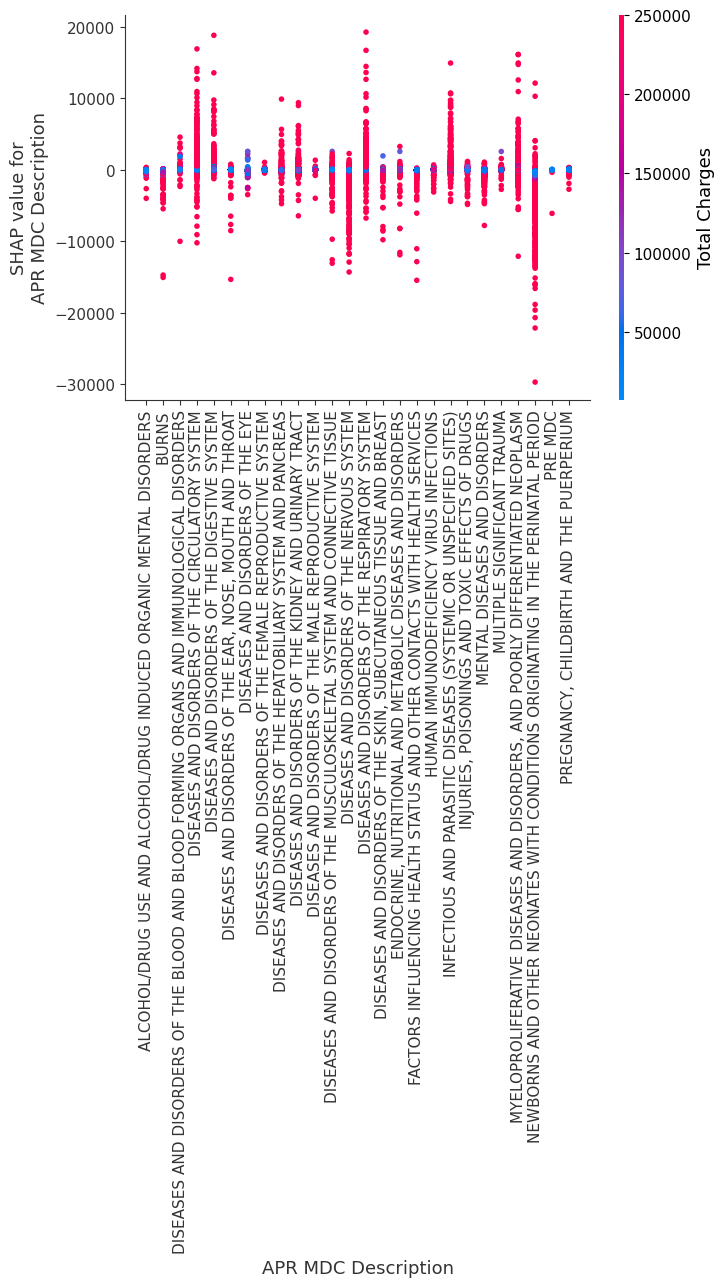

In [35]:
feature_index = 21
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

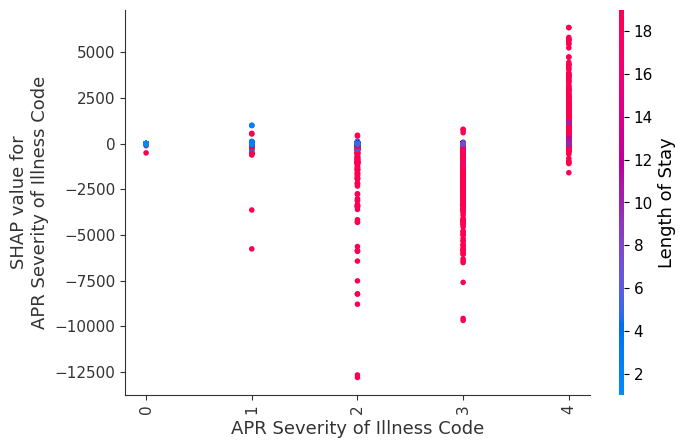

In [36]:
feature_index = 22
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

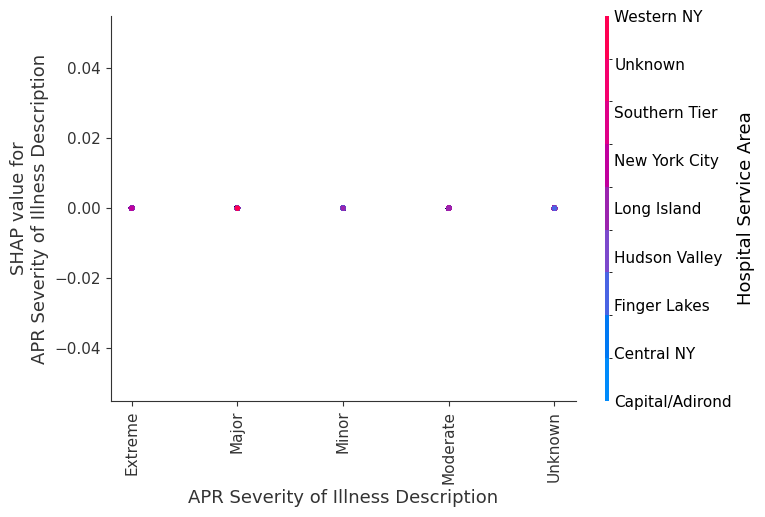

In [37]:
feature_index = 23
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

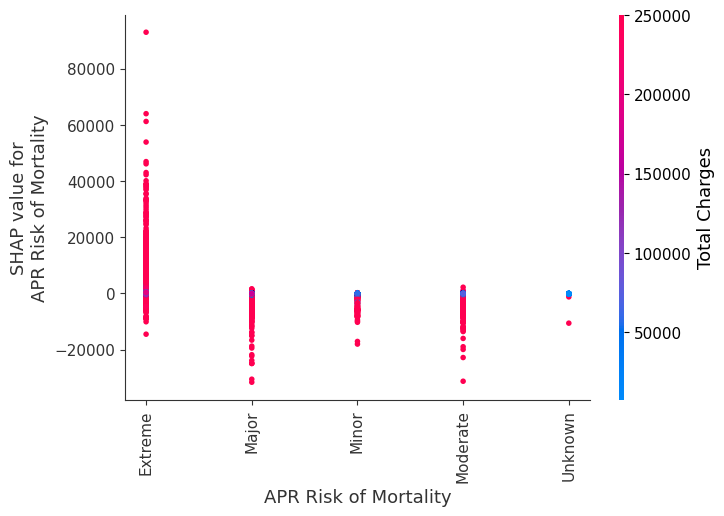

In [38]:
feature_index = 24
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

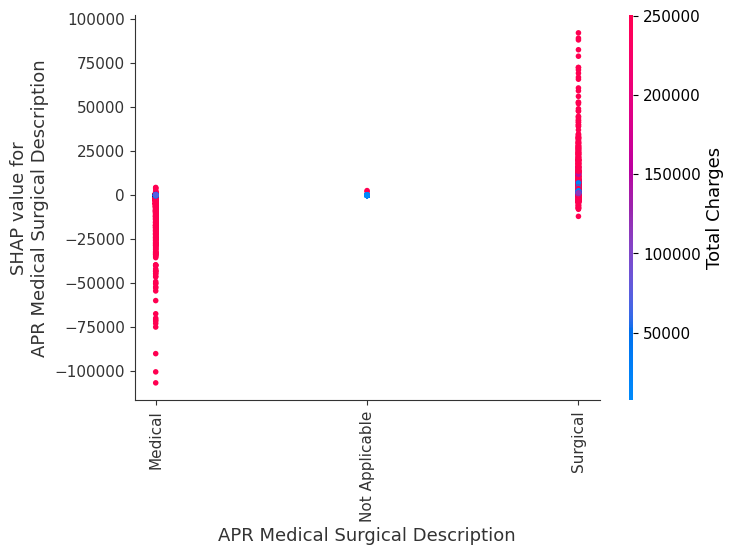

In [39]:
feature_index = 25
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

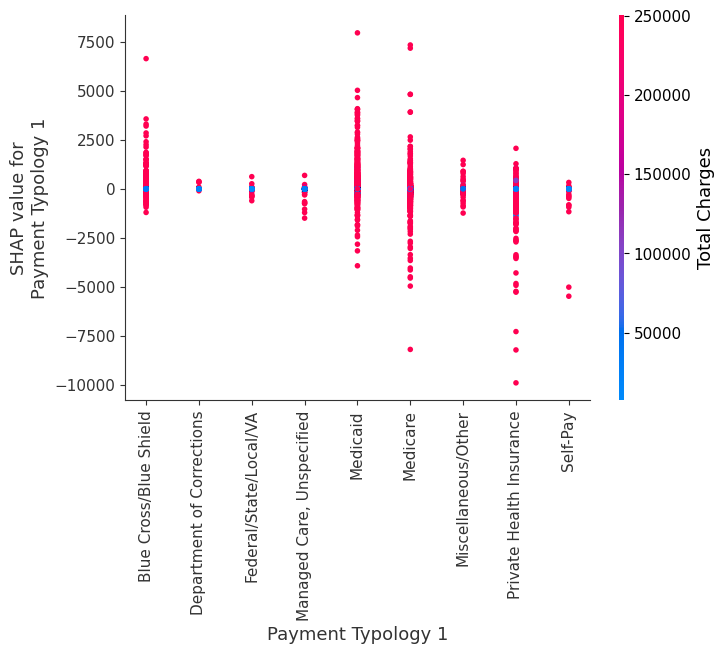

In [40]:
feature_index = 26
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

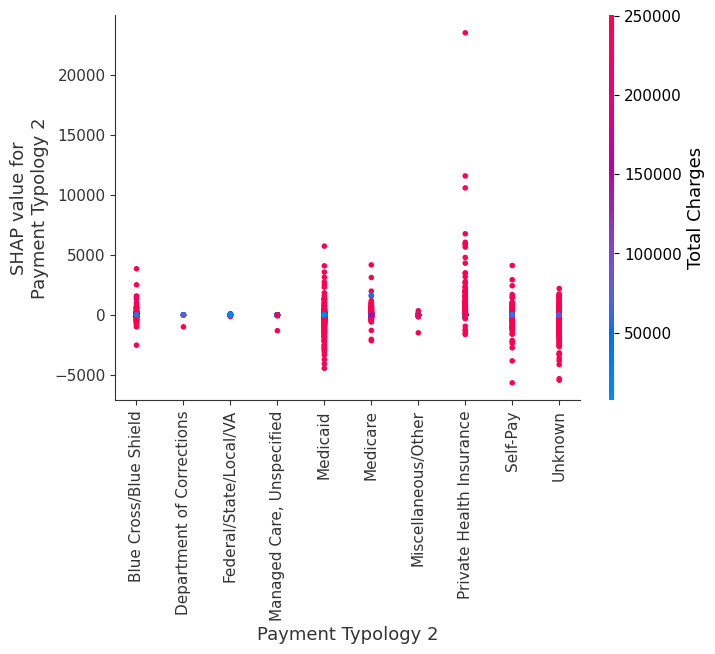

In [41]:
feature_index = 27
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

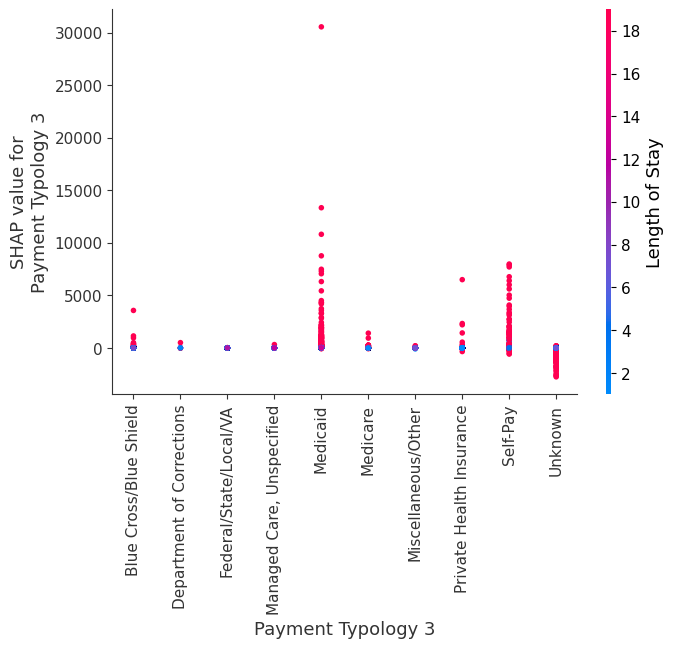

In [42]:
feature_index = 28
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

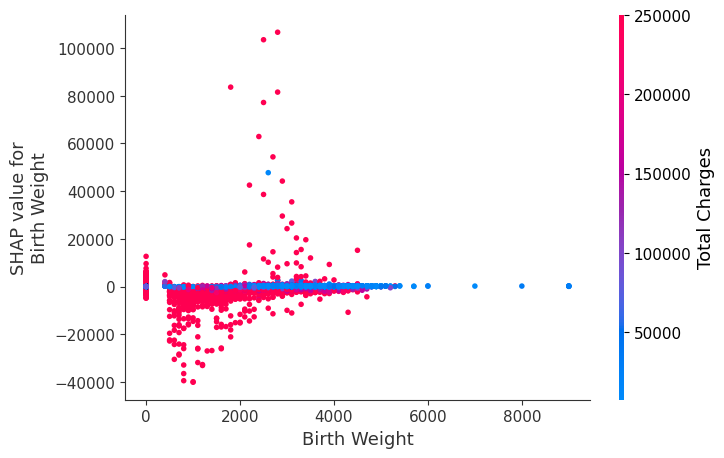

In [43]:
feature_index = 29
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

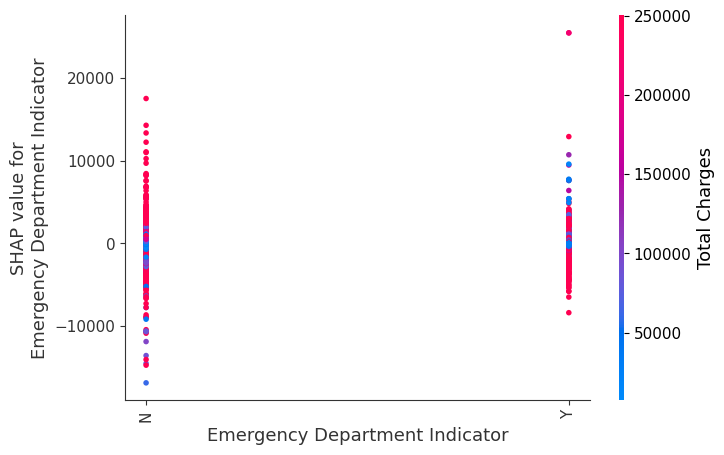

In [44]:
feature_index = 30
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

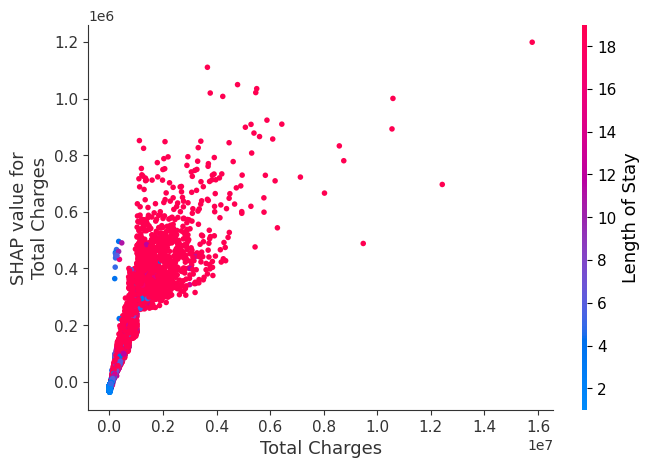

In [45]:
feature_index = 31
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

In [46]:
shap.initjs()

instance_index = 0
shap.force_plot(explainer.expected_value, shap_values[instance_index], X_test.iloc[instance_index], feature_names=features)

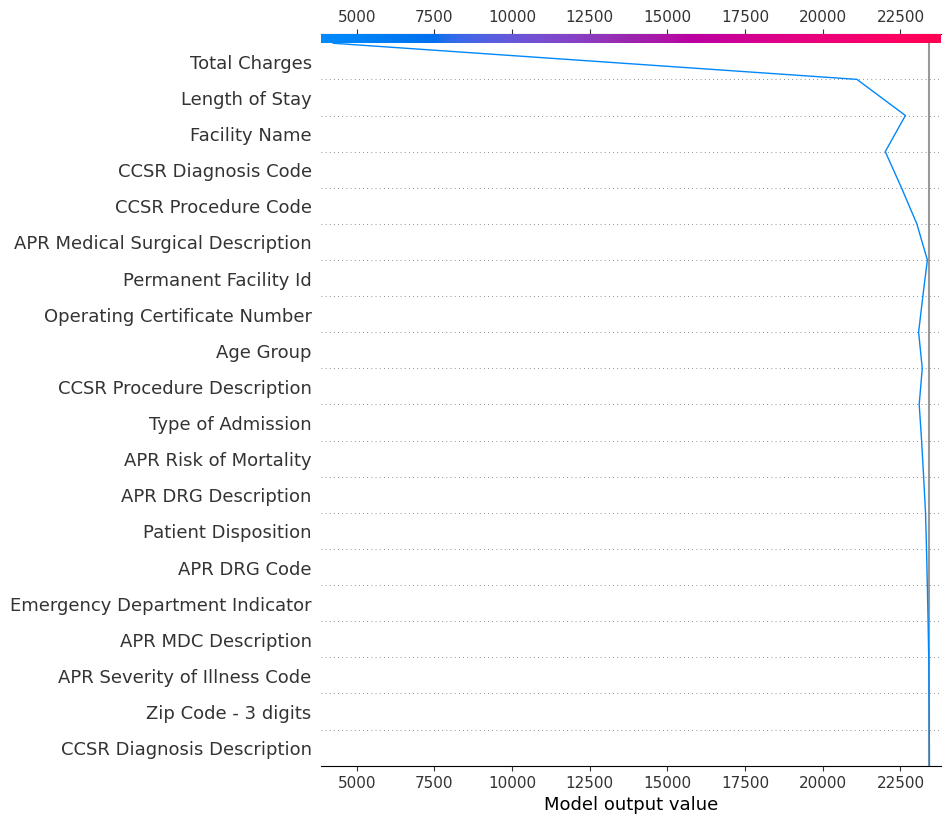

In [47]:
shap.decision_plot(explainer.expected_value, shap_values[0], feature_names=features)

In [ ]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


data_temp = data.copy()

for col in data_temp.select_dtypes(include='category').columns:
    le = LabelEncoder()
    data_temp[col] = le.fit_transform(data_temp[col].astype(str))

X = data_temp.drop(columns=['Total Costs', ])
y = data_temp['Total Costs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# LIME explainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# test sample
query_instance = X_test.iloc[0]

# get LIME explanations
exp = explainer.explain_instance(
    data_row=query_instance.values,
    predict_fn=model.predict,
    num_features=10
)

In [ ]:
exp.show_in_notebook(show_table=True)

print("Prediction:", model.predict([query_instance.values])[0])
print("LIME Explanation:")
print(exp.as_list())